# Unsupervised Analysis of Dataset

This notebook performs exploratory data analysis, PCA, and KMeans clustering on `dataset.csv` without using the target column.

## 1. Load and Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset, mark '?' as NaN
df = pd.read_csv('dataset.csv', na_values='?')

# Clean price columns
price_cols = ['open','high','low','close','next_weeks_open','next_weeks_close']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

# Parse date if needed (optional)
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y', errors='coerce')

# Drop unnecessary and missing data
df = df.drop(['stock','quarter','date'], axis=1).dropna()

# Separate features (drop target)
target_col = df.columns[-1]
X = df.drop(columns=[target_col])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 2. Exploratory Data Analysis (EDA)

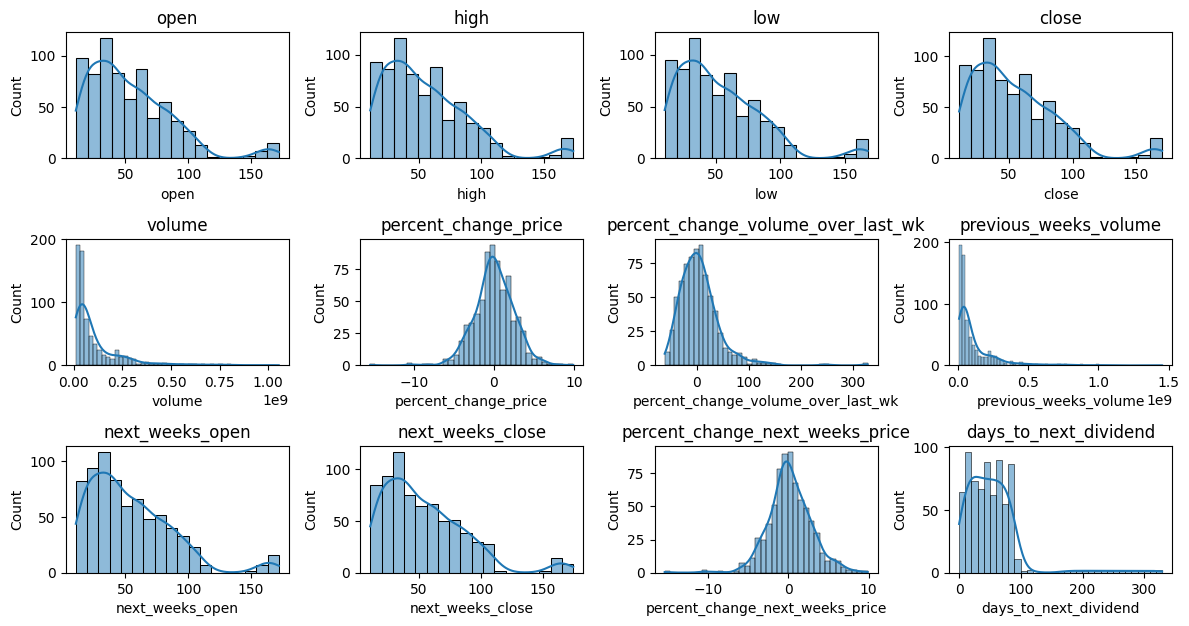

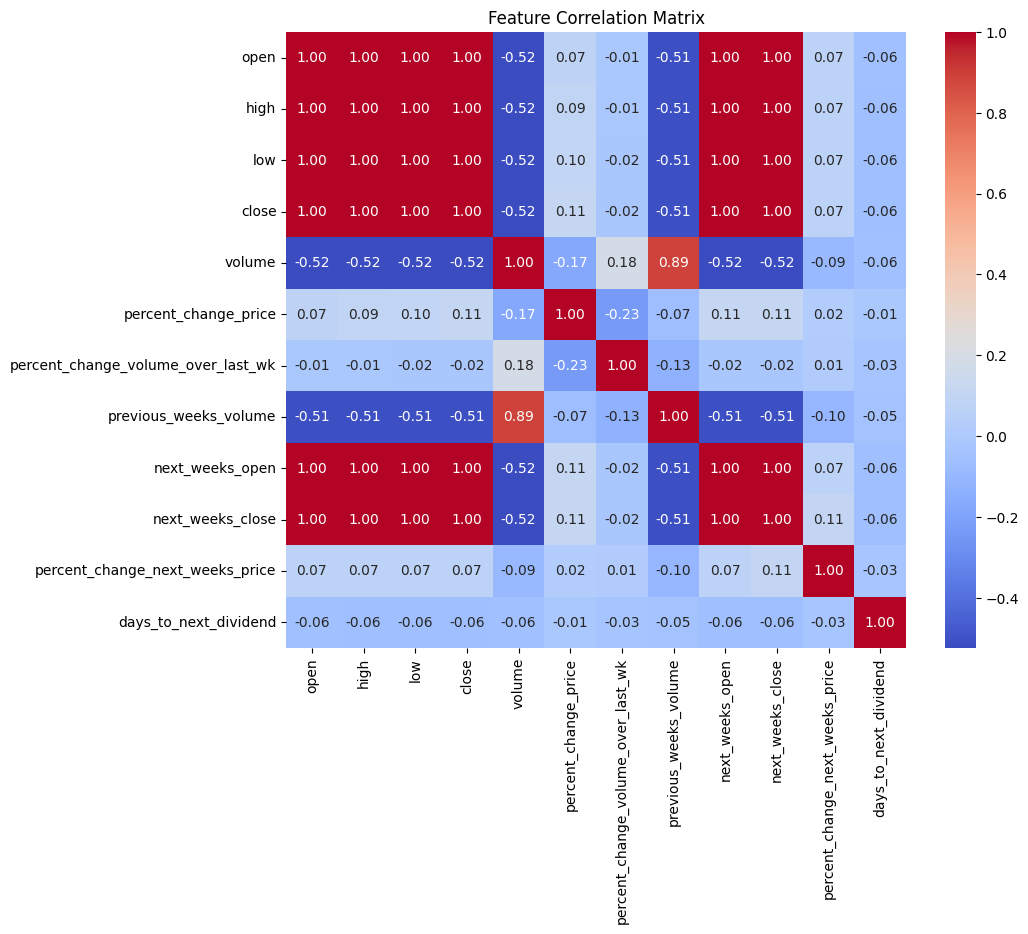

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for each feature
plt.figure(figsize=(12, 8))
for i, col in enumerate(X.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = pd.DataFrame(X_scaled, columns=X.columns).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


## 3. Dimensionality Reduction with PCA

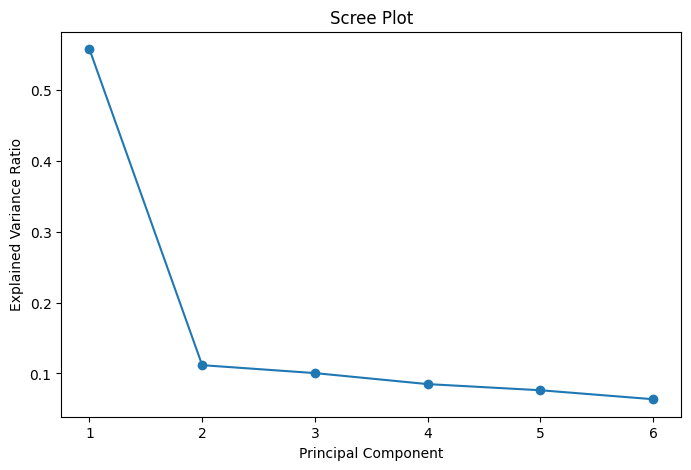

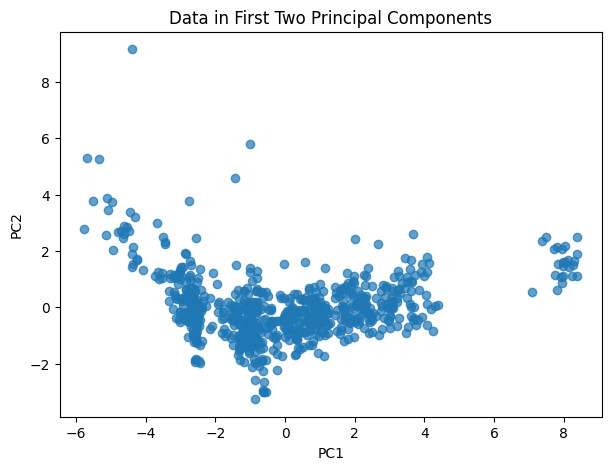

In [4]:
from sklearn.decomposition import PCA

# PCA to retain 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.show()

# First two components scatter
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data in First Two Principal Components')
plt.show()


## 4. Clustering with KMeans

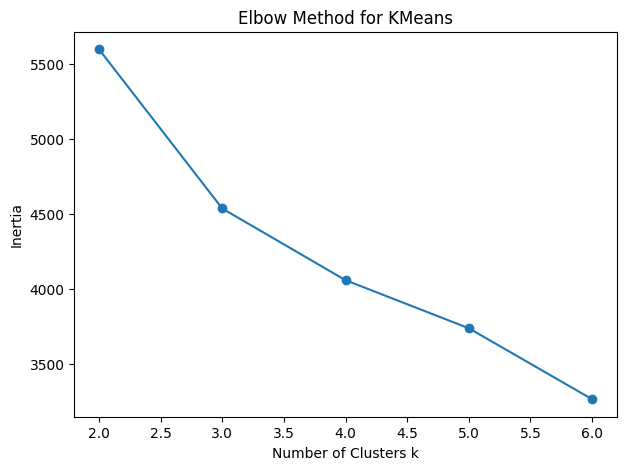

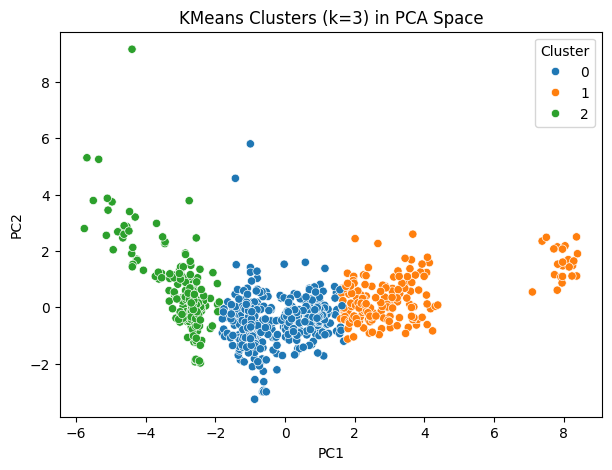

In [5]:
from sklearn.cluster import KMeans

# Elbow method
inertias = []
ks = range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')
plt.show()

# Choose optimal k (e.g., 3) and fit
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Scatter of clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans Clusters (k={optimal_k}) in PCA Space')
plt.legend(title='Cluster')
plt.show()


## 5. Cluster Analysis

Examples per cluster:
   cluster  count
0        0    367
1        1    179
2        2    174


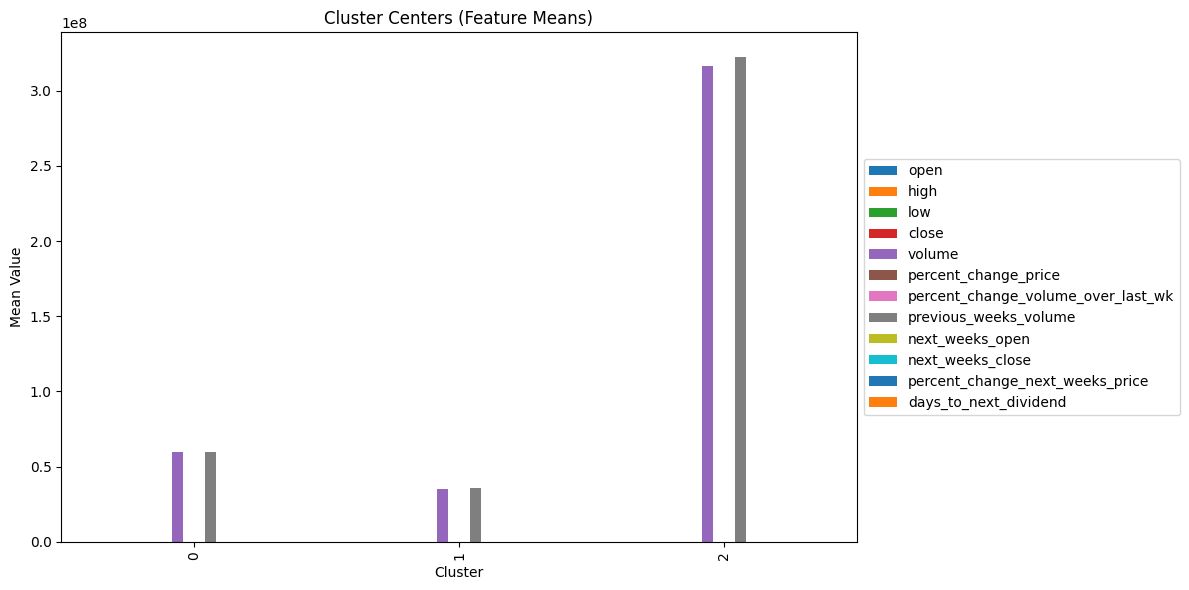

In [6]:
import numpy as np

# Attach cluster labels to original
df_clusters = X.copy()
df_clusters['cluster'] = clusters

# Number of examples per cluster
count_series = df_clusters['cluster'].value_counts().sort_index()
counts = pd.DataFrame({'cluster': count_series.index, 'count': count_series.values})
print('Examples per cluster:')
print(counts)

# Cluster centers (means of original features)
centers = df_clusters.groupby('cluster').mean()

# Bar plot of feature means per cluster
centers.plot(kind='bar', figsize=(12, 6))
plt.title('Cluster Centers (Feature Means)')
plt.xlabel('Cluster')
plt.ylabel('Mean Value')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


## 6. Optional: Relate to Target Variable

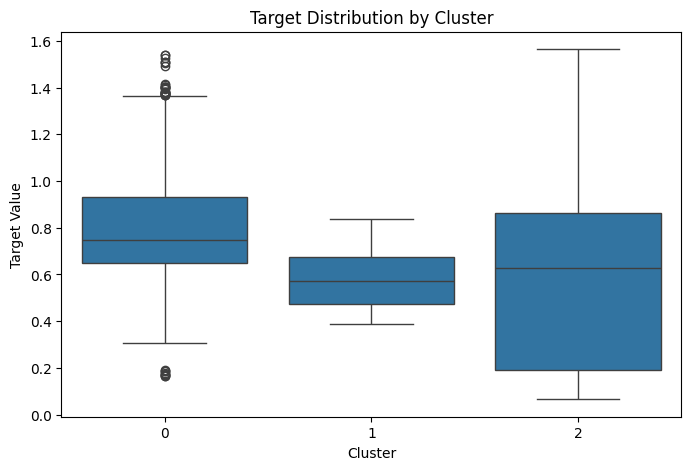

In [7]:
# If target is desired for interpretation
df_target = pd.read_csv('dataset.csv', na_values='?').dropna()
df_target['date'] = pd.to_datetime(df_target['date'], format='%m/%d/%Y', errors='coerce')
df_target = df_target.drop(['stock','quarter','date'], axis=1).dropna()

# Attach clusters and target
df_target['cluster'] = clusters
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=df_target.columns[-2], data=df_target)
plt.title('Target Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Target Value')
plt.show()


## 7. Conclusions and Discussion

### 7.1 Key Findings from EDA  
- **Feature distributions**  
  - Price columns (`open`, `high`, `low`, `close`, `next_weeks_open`, `next_weeks_close`) are roughly right‐skewed, with a long tail toward higher values.  
  - Volume features (`volume`, `previous_weeks_volume`) show extreme positive skew—most weeks trade low volume, with occasional spikes.  
  - Percent‐change features are more symmetrically distributed, suggesting both up‐ and down‐weeks occur regularly.  
  - `days_to_next_dividend` clusters around smaller values with a drop‐off after ~100 days, reflecting a calendar‐driven schedule.

- **Correlation structure**  
  - The four price columns are nearly perfectly correlated (r≈1), so they move in lockstep.  
  - Volume and previous week’s volume are strongly correlated (r≈0.89), but uncorrelated with price movements.  
  - Percent‐change features show only weak correlations with price levels (|r|<0.2), indicating returns are not driven by absolute price.

---

### 7.2 PCA Insights  
- **Variance explained**  
  - PC 1 captures ≈56% of total variance, mostly driven by the four price features moving together.  
  - PC 2 explains ≈11%, dominated by volume vs. previous‐volume contrasts.  
  - By PC 6 we exceed 95% cumulative variance, so we reduced dimensionality from ~12 to 6 components.

- **First two PCs scatter**  
  - The cloud of points in PC 1 vs. PC 2 shows a continuum from low‐price, low‐volume weeks (left/lower) to high‐price, high‐volume weeks (right/upper).  
  - A handful of outliers appear at extreme high‐volume or high‐price ends.

---

### 7.3 Choice of K and Cluster Separation  
- **Elbow method**  
  - Inertia drops sharply from k=2 to k=3, then gradually thereafter—suggesting **k=3** strikes a good balance between compactness and simplicity.

- **Cluster visualization**  
  - In PC space, three clusters separate well along PC 1:  
    1. **Cluster 0 (mid-PC1)**: the densest group, moderate price & volume.  
    2. **Cluster 1 (lower-PC1)**: lower‐price, lower‐volume weeks.  
    3. **Cluster 2 (higher-PC1)**: higher‐price, higher‐volume weeks, including a few extreme outliers.

---

### 7.4 Cluster Profiles & Interpretations  
- **Sizes**:  
  - Cluster 0: 367 examples  
  - Cluster 1: 179 examples  
  - Cluster 2: 174 examples  

- **Centroid bar plot**  
  - **Cluster 1** has the lowest mean price and volume—perhaps representing quieter trading periods or smaller‐cap stocks.  
  - **Cluster 2** shows the highest mean price and volume—likely representing high‐liquidity, high‐cap stocks or news‐driven spikes.  
  - **Cluster 0** sits in between, representing the “typical” trading weeks.

- **Relationship to the target**  
  - Boxplots of the original target by cluster reveal:  
    - **Cluster 1** (low‐price/low‐volume) has the lowest median target and tightest spread.  
    - **Cluster 2** (high‐price/high‐volume) shows a wide target distribution with higher upper quartiles—possibly capturing both very strong and very weak follow‐on returns.  
    - **Cluster 0** sits in the middle with moderate median target and moderate variance.

---

### 7.5 Next Steps  
- **Validate clusters** against additional labels (e.g., sector, market cap) to see if they align with known groupings.  
- **Try alternative clustering** (DBSCAN, hierarchical) to detect non-spherical clusters or noise points.  
- **Feature refinement**: collapse the four price features into a single “average price” or use price ratios to reduce multicollinearity before clustering.  
- **Temporal analysis**: track cluster membership over time to see if markets move between regimes (e.g., from quiet to high‐volatility weeks).

Overall, the unsupervised pipeline uncovered three distinct market regimes—quiet weeks, typical trading, and high‐activity weeks—with clear separation in PCA space and interpretable differences in the original data and subsequent target behavior.